# Regressão — Communities and Crime

Pipeline de regressão supervisionada sobre o dataset **Communities and Crime** (UCI id=183), alvo `ViolentCrimesPerPop`. Modelos: Regressão Linear, Ridge e Lasso.

## Configuração

Importações, constantes e funções auxiliares reutilizadas em múltiplas etapas.

In [192]:
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, GridSearchCV, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, linear_reset

warnings.filterwarnings('ignore')

TARGET = 'ViolentCrimesPerPop'

In [193]:
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2_score(y_true, y_pred)}


def construir_pipeline(modelo):
    return Pipeline([('scaler', StandardScaler()), ('modelo', modelo)])

## Carregamento dos Dados

Dataset obtido via `ucimlrepo` (id=183). Features e target combinados em um único DataFrame.

In [194]:
dataset = fetch_ucirepo(id=183)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f'Shape: {df.shape}')
df.head()

Shape: (1994, 128)


,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14,0.20
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,?,?,?,?,0.00,?,0.67
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,?,?,?,?,0.00,?,0.43
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,?,?,?,?,0.00,?,0.12
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,?,?,?,?,0.00,?,0.03


## Exploração Inicial

Tipos de dados, dimensões e estatísticas descritivas para entender a estrutura do dataset antes de qualquer transformação.

In [195]:
print(f'Linhas: {df.shape[0]}  |  Colunas: {df.shape[1]}')
display(df.dtypes.value_counts().rename('contagem').to_frame())
df.describe().T.round(4)

Linhas: 1994  |  Colunas: 128


,contagem
float64,100
object,26
int64,2


,count,mean,std,min,25%,50%,75%,max
state,1994.0,28.6836,16.3976,1.0,12.00,34.00,42.00,56.0
fold,1994.0,5.4940,2.8737,1.0,3.00,5.00,8.00,10.0
population,1994.0,0.0576,0.1269,0.0,0.01,0.02,0.05,1.0
householdsize,1994.0,0.4634,0.1637,0.0,0.35,0.44,0.54,1.0
racepctblack,1994.0,0.1796,0.2534,0.0,0.02,0.06,0.23,1.0
...,...,...,...,...,...,...,...,...
LandArea,1994.0,0.0652,0.1095,0.0,0.02,0.04,0.07,1.0
PopDens,1994.0,0.2329,0.2031,0.0,0.10,0.17,0.28,1.0
PctUsePubTrans,1994.0,0.1617,0.2291,0.0,0.02,0.07,0.19,1.0
LemasPctOfficDrugUn,1994.0,0.0941,0.2403,0.0,0.00,0.00,0.00,1.0


## Valores Ausentes

Quantificação e visualização dos missing values por coluna. Colunas com `?` são tratadas como `NaN`.

In [196]:
df_tmp = df.replace('?', np.nan)
missing = df_tmp.isna().sum()
tabela_missing = pd.DataFrame({
    'missing':    missing,
    'percentual': (missing / len(df_tmp) * 100).round(2),
}).sort_values('missing', ascending=False)
tabela_missing[tabela_missing['missing'] > 0].head(3)

,missing,percentual
PolicReqPerOffic,1675,84.0
PolicAveOTWorked,1675,84.0
PolicPerPop,1675,84.0


## Pré-processamento

Limpeza sequencial:
1. Substituição de `?` por `NaN`
2. Remoção da coluna `fold` (artefato de CV do UCI)
3. Conversão numérica (colunas não-categóricas)
4. Remoção de colunas com ≥ 50% de missing
5. Filtro de esparsidade em colunas categóricas (n_distinct/n_total > 0.5 → remove)
6. One-Hot Encoding nas categóricas restantes

In [197]:
df = df.copy()
df.replace('?', np.nan, inplace=True)

if 'fold' in df.columns:
    df.drop(columns=['fold'], inplace=True)

COLS_ID = ['state', 'county', 'community', 'communityname']
cols_id = [c for c in COLS_ID if c in df.columns]
n_total = len(df)

for col in df.columns:
    if col not in cols_id:
        df[col] = pd.to_numeric(df[col], errors='coerce')

limite = int(n_total * 0.50)
muito_missing = df.columns[df.isna().sum() >= limite].tolist()
if TARGET in muito_missing:
    muito_missing.remove(TARGET)
df.drop(columns=muito_missing, inplace=True)

cols_id = [c for c in cols_id if c in df.columns]
removidas_sparsity = []
cols_categoricas_mantidas = []
for col in cols_id:
    sparsity = df[col].nunique(dropna=True) / n_total
    if sparsity > 0.5:
        removidas_sparsity.append(col)
    else:
        cols_categoricas_mantidas.append(col)

df.drop(columns=removidas_sparsity, inplace=True)
print(f'Colunas removidas por missing (≥50%): {len(muito_missing)}')
print(f'Categóricas removidas por sparsity:   {removidas_sparsity or "nenhuma"}')
print(f'Categóricas mantidas para OHE:        {cols_categoricas_mantidas or "nenhuma"}')
print(f'Shape após limpeza: {df.shape}')

Colunas removidas por missing (≥50%): 24
Categóricas removidas por sparsity:   ['communityname']
Categóricas mantidas para OHE:        ['state']
Shape após limpeza: (1994, 102)


In [198]:
if cols_categoricas_mantidas:
    df = pd.get_dummies(df, columns=cols_categoricas_mantidas, drop_first=True, dtype=float)
    print(f'Shape após OHE: {df.shape}')
else:
    print('Nenhuma coluna categórica para encoding.')

Shape após OHE: (1994, 146)


In [199]:
# ── Divisão Treino / Teste ────────────────────────────────────────────────────
# Split ANTES de qualquer fit — elimina data leakage em imputação, Box-Cox e LassoCV
X_raw = df.drop(columns=[TARGET])
y     = df[TARGET]

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print(f'Treino: {X_raw_train.shape[0]} amostras  |  Teste: {X_raw_test.shape[0]} amostras')

# ── Imputação por Mediana (fit no treino) ─────────────────────────────────────
train_medians = X_raw_train.median(numeric_only=True)
X_train_imp   = X_raw_train.fillna(train_medians)
X_test_imp    = X_raw_test.fillna(train_medians)
print(f'NaN restantes — treino: {X_train_imp.isna().sum().sum()}  |  teste: {X_test_imp.isna().sum().sum()}')

Treino: 1595 amostras  |  Teste: 399 amostras
NaN restantes — treino: 0  |  teste: 0


## Caracterização Demográfica

Perfil médio das comunidades nos eixos racial, econômico, etário e familiar. Dados normalizados entre 0 e 1 pelo dataset original.

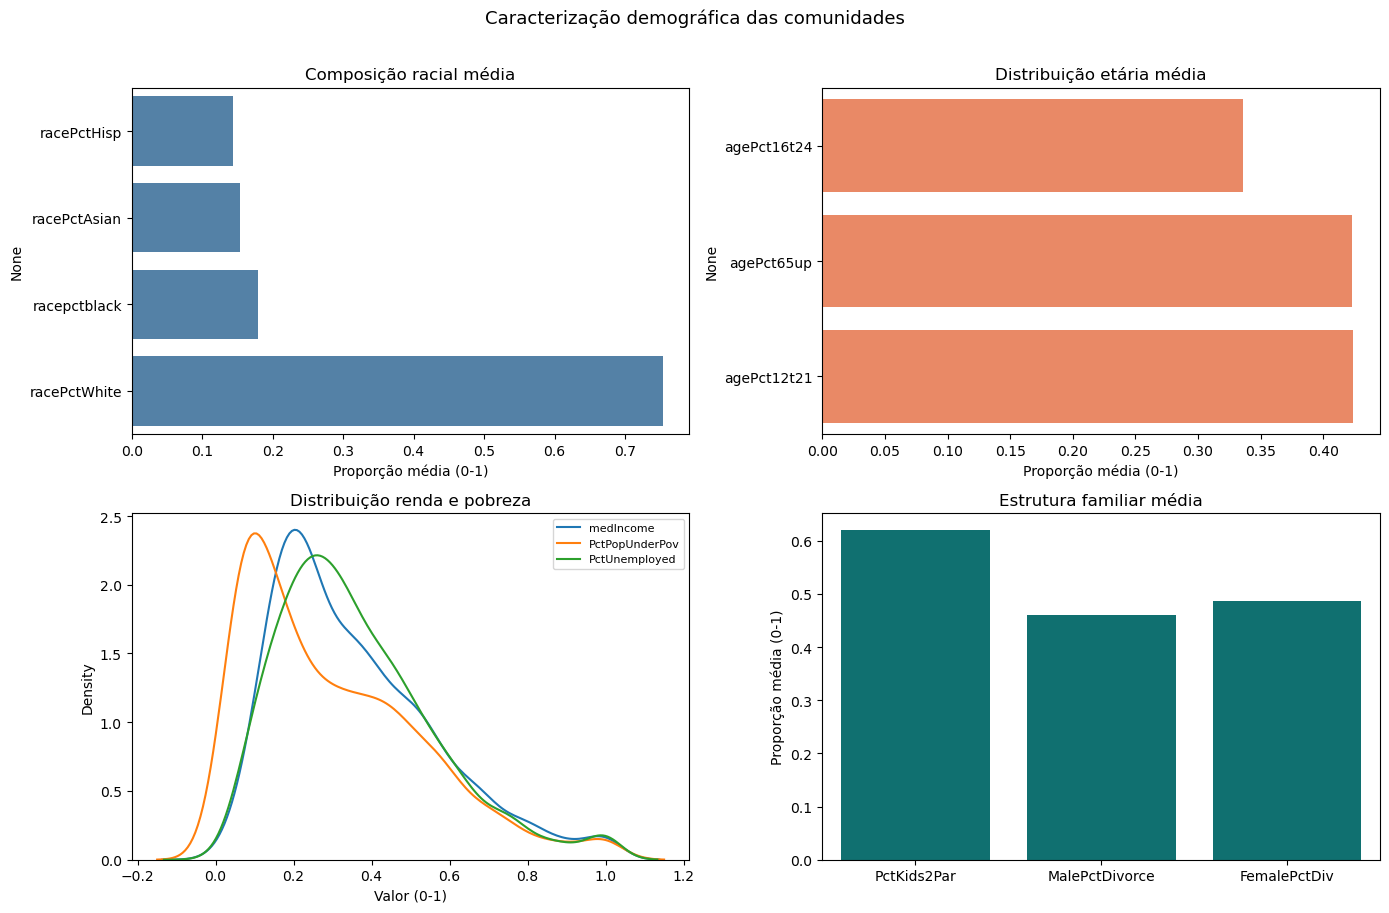

In [200]:
df_plot = df.fillna(df.median(numeric_only=True))

raciais  = [c for c in ['racepctblack','racePctWhite','racePctAsian','racePctHisp'] if c in df_plot.columns]
etarias  = [c for c in ['agePct12t21','agePct16t24','agePct65up'] if c in df_plot.columns]
renda_c  = [c for c in ['medIncome','PctPopUnderPov','PctUnemployed'] if c in df_plot.columns]
familia  = [c for c in ['PctKids2Par','MalePctDivorce','FemalePctDiv'] if c in df_plot.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

if raciais:
    m = df_plot[raciais].mean().sort_values()
    sns.barplot(x=m.values, y=m.index, color='steelblue', orient='h', ax=axes[0,0])
    axes[0,0].set_title('Composição racial média')
    axes[0,0].set_xlabel('Proporção média (0-1)')

if etarias:
    m = df_plot[etarias].mean().sort_values()
    sns.barplot(x=m.values, y=m.index, color='coral', orient='h', ax=axes[0,1])
    axes[0,1].set_title('Distribuição etária média')
    axes[0,1].set_xlabel('Proporção média (0-1)')

if renda_c:
    for i, col in enumerate(renda_c):
        ax_r = axes[1,0] if i == 0 else None
    # distribuição de renda num único histograma stacked
    for col in renda_c:
        sns.kdeplot(data=df_plot, x=col, ax=axes[1,0], label=col)
    axes[1,0].set_title('Distribuição renda e pobreza')
    axes[1,0].set_xlabel('Valor (0-1)')
    axes[1,0].legend(fontsize=8)

if familia:
    m = df_plot[familia].mean()
    sns.barplot(x=list(m.index), y=list(m.values), color='teal', ax=axes[1,1])
    axes[1,1].set_title('Estrutura familiar média')
    axes[1,1].set_ylabel('Proporção média (0-1)')

plt.suptitle('Caracterização demográfica das comunidades', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [201]:
# df_analise: imputação pela mediana global — usado SOMENTE para EDA/visualização
# Nenhum fit ocorre sobre estes dados; pipeline de modelagem usa X_train_imp / X_train_bc
df_analise = df.fillna(df.median(numeric_only=True))

correlacoes = df_analise.corr(numeric_only=True)[TARGET].drop(TARGET)
tabela_corr = (pd.DataFrame({'correlacao': correlacoes, 'correlacao_abs': correlacoes.abs()})
               .sort_values('correlacao_abs', ascending=False))

print(f'[EDA] df_analise shape: {df_analise.shape}  (visualização apenas — não usado no modelo)')
print(f'Top 5 correlações com {TARGET}:')
display(tabela_corr.head())

[EDA] df_analise shape: (1994, 146)  (visualização apenas — não usado no modelo)
Top 5 correlações com ViolentCrimesPerPop:


,correlacao,correlacao_abs
PctKids2Par,-0.738424,0.738424
PctIlleg,0.737957,0.737957
PctFam2Par,-0.706667,0.706667
racePctWhite,-0.684770,0.684770
PctYoungKids2Par,-0.666059,0.666059


### Distribuição — Todas as Features Numéricas

Assimetria e outliers em todas as features antes de qualquer transformação. Identifica quais serão tratadas com Box-Cox.

In [202]:
# Apenas features contínuas (nunique > 2 exclui dummies binárias 0/1)
cols_numericas = [
    c for c in df_analise.select_dtypes(include='number').columns
    if c != TARGET and df_analise[c].nunique() > 2
]

def _calc_stats(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = s[(s < lo) | (s > hi)]
    n   = len(out)
    dev = abs(out - s.median()).max() / (iqr if iqr > 0 else 1) if n > 0 else 0.0
    return {'skew': s.skew(), 'n_out': n, 'pct': 100 * n / len(s), 'dev': dev}

rows = []
for col in cols_numericas:
    st = _calc_stats(df_analise[col].dropna())
    rows.append({'Feature': col, 'Assimetria': st['skew'], 'N Outliers': st['n_out'],
                 '% Outliers': st['pct'], 'Desvio max (IQR)': st['dev']})

df_dist_all = pd.DataFrame(rows).set_index('Feature').sort_values('Assimetria', key=abs, ascending=False)
print(f'{len(cols_numericas)} features contínuas (binárias/dummies excluídas)')
df_dist_all.style     .format({'Assimetria': '{:+.3f}', 'N Outliers': '{:d}', '% Outliers': '{:.1f}%', 'Desvio max (IQR)': '{:.2f}x'})     .set_caption('Distribuições — features contínuas (excl. target e dummies, pré Box-Cox)')

100 features contínuas (binárias/dummies excluídas)


,Assimetria,N Outliers,% Outliers,Desvio max (IQR)
Feature,,,,
NumImmig,+7.472,245,12.3%,49.50x
NumStreet,+7.020,397,19.9%,1.00x
NumInShelters,+6.740,396,19.9%,100.00x
NumIlleg,+6.273,247,12.4%,49.50x
LandArea,+5.708,159,8.0%,19.20x
NumUnderPov,+5.181,196,9.8%,24.50x
population,+5.064,218,10.9%,24.50x
numbUrban,+4.840,136,6.8%,13.86x
HousVacant,+4.294,186,9.3%,16.17x


In [203]:
from scipy.stats import boxcox as _boxcox

LIMIAR_PCT  = 5.0
LIMIAR_SKEW = 1.0

# Colunas candidatas identificadas APENAS no treino
cols_num_train = [
    c for c in X_train_imp.select_dtypes(include='number').columns
    if X_train_imp[c].nunique() > 2
]

cols_transformar = [
    col for col in cols_num_train
    if _calc_stats(X_train_imp[col].dropna())['pct'] > LIMIAR_PCT
    or abs(_calc_stats(X_train_imp[col].dropna())['skew']) > LIMIAR_SKEW
]

X_train_bc = X_train_imp.copy()
X_test_bc  = X_test_imp.copy()
bc_params  = {}

def _apply_boxcox(series, lam, shift):
    x = (series + shift).clip(lower=1e-10)
    if abs(lam) < 1e-10:
        return np.log(x)
    return (np.power(x, lam) - 1) / lam

for col in cols_transformar:
    s = X_train_imp[col].dropna()
    shift = max(0.0, -s.min() + 1e-6)
    try:
        bc_vals, lam = _boxcox(s + shift)
        X_train_bc.loc[s.index, col] = bc_vals
        X_test_bc[col] = _apply_boxcox(X_test_imp[col], lam, shift)
        bc_params[col] = (lam, shift)
    except Exception:
        pass

print(f'Box-Cox fit no treino: {len(bc_params)} / {len(cols_num_train)} features transformadas')
print(f'X_train_bc: {X_train_bc.shape}  |  X_test_bc: {X_test_bc.shape}')

Box-Cox fit no treino: 53 / 100 features transformadas
X_train_bc: (1595, 145)  |  X_test_bc: (399, 145)


## Seleção de Features — LassoCV

LassoCV (cv=5) com alpha ótimo escolhido por validação cruzada. Fit **exclusivamente no treino** (`X_train_bc`) — sem acesso ao conjunto de teste. Features com coeficiente zero são descartadas.

In [204]:
X_lasso = X_train_bc
y_lasso = y_train

scaler_lasso   = StandardScaler()
X_lasso_scaled = scaler_lasso.fit_transform(X_lasso)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=20000)
lasso_cv.fit(X_lasso_scaled, y_lasso)

coefs_lasso             = pd.Series(lasso_cv.coef_, index=X_lasso.columns)
alpha_lasso             = lasso_cv.alpha_
selected_features_lasso = coefs_lasso[coefs_lasso.abs() > 0].index.tolist()

print(f'Alpha ótimo: {alpha_lasso:.6f}')
print(f'Features selecionadas: {len(selected_features_lasso)} / {X_lasso.shape[1]}')
coefs_lasso[selected_features_lasso].sort_values(key=abs, ascending=False).round(4)

Alpha ótimo: 0.001072
Features selecionadas: 90 / 145


racePctWhite     -0.0550
PctKids2Par      -0.0535
state_12          0.0332
PersPerFam        0.0328
MalePctDivorce    0.0247
                   ...  
state_55          0.0004
state_42         -0.0004
state_16          0.0001
state_41         -0.0001
state_29          0.0000
Length: 90, dtype: float64

## Preparação das Features Finais

Extração das features selecionadas pelo LassoCV dos conjuntos treino e teste (já pós Box-Cox). Split foi realizado antes de qualquer fit.

In [205]:
X_train = X_train_bc[selected_features_lasso].copy()
X_test  = X_test_bc[selected_features_lasso].copy()
print(f'Treino: {X_train.shape[0]} amostras  |  Teste: {X_test.shape[0]} amostras')
print(f'Features selecionadas: {X_train.shape[1]}')

Treino: 1595 amostras  |  Teste: 399 amostras
Features selecionadas: 90


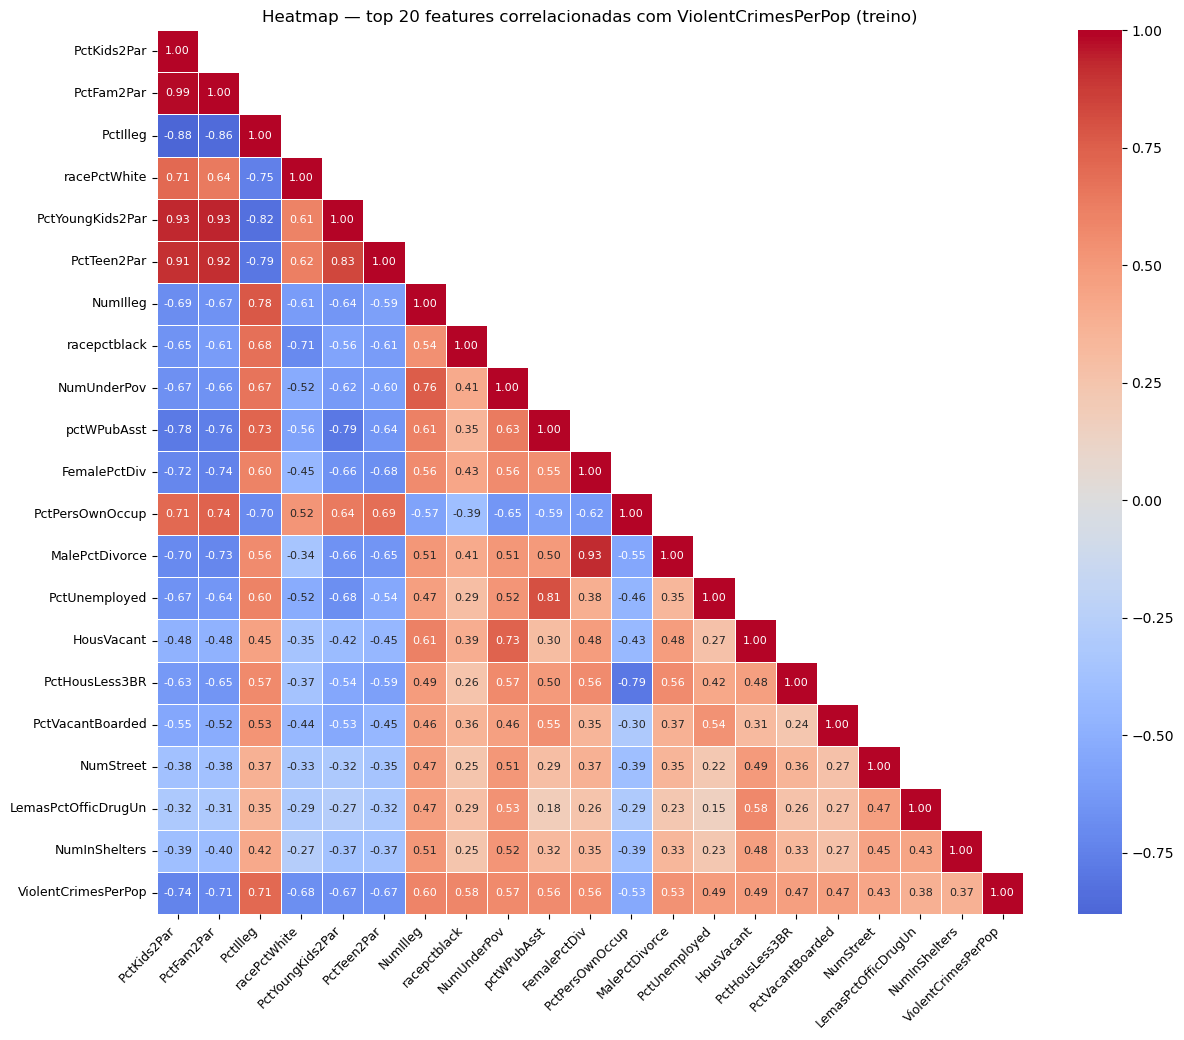

In [206]:
features_sem_state = [f for f in selected_features_lasso if not f.startswith('state_')]

# Heatmap construído sobre treino — sem contaminação do conjunto de teste
df_heat = X_train_bc[features_sem_state].copy()
df_heat[TARGET] = y_train.values
corr_lasso = df_heat.corr()

top20      = (corr_lasso[TARGET].drop(TARGET).abs()
              .sort_values(ascending=False).head(20).index.tolist())
cols_top20 = top20 + [TARGET]

corr_top20 = df_heat[cols_top20].corr()
mask_top20 = np.triu(np.ones_like(corr_top20, dtype=bool), k=1)
n2 = len(cols_top20)

fig, ax = plt.subplots(figsize=(n2 * 0.6, n2 * 0.5))
sns.heatmap(corr_top20, mask=mask_top20, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, annot_kws={'size': 8}, ax=ax)
ax.set_title(f'Heatmap — top 20 features correlacionadas com {TARGET} (treino)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Distribuições — Features Contínuas Selecionadas pelo LassoCV

In [207]:
features_continuas = [f for f in selected_features_lasso if not f.startswith('state_')]

rows = []
for col in features_continuas:
    s  = X_train_bc[col].dropna()
    st = _calc_stats(s)
    rows.append({'Feature': col, 'Assimetria': st['skew'], 'N Outliers': st['n_out'],
                 '% Outliers': st['pct'], 'Desvio max (IQR)': st['dev']})

st_y = _calc_stats(y_train.dropna())
rows.append({'Feature': TARGET + ' (original)', 'Assimetria': st_y['skew'],
             'N Outliers': st_y['n_out'], '% Outliers': st_y['pct'], 'Desvio max (IQR)': st_y['dev']})

df_dist_sel = pd.DataFrame(rows).set_index('Feature').sort_values('Assimetria', key=abs, ascending=False)
df_dist_sel.style \
    .format({'Assimetria': '{:+.3f}', 'N Outliers': '{:d}', '% Outliers': '{:.1f}%', 'Desvio max (IQR)': '{:.2f}x'}) \
    .set_caption(f'Distribuições pós Box-Cox (treino) — {len(features_continuas)} features selecionadas + target')

,Assimetria,N Outliers,% Outliers,Desvio max (IQR)
Feature,,,,
LemasPctOfficDrugUn,+1.814,262,16.4%,1151.49x
ViolentCrimesPerPop (original),+1.487,95,6.0%,3.23x
NumStreet,+1.472,325,20.4%,955.83x
PctHousOccup,-1.358,64,4.0%,2.95x
racePctWhite,-1.095,45,2.8%,2.31x
PctSameState85,-1.033,58,3.6%,2.60x
PctImmigRecent,+0.973,62,3.9%,2.73x
PctUnemployed,+0.954,43,2.7%,2.58x
MedOwnCostPctIncNoMtg,+0.906,45,2.8%,2.52x


In [208]:
# ── Transformação do Target — log1p ───────────────────────────────────────────
# ViolentCrimesPerPop é right-skewed e bounded em [0,1].
# log1p reduz assimetria e melhora homoscedasticidade no OLS.
# Predições são revertidas com expm1 para avaliação na escala original.
from scipy.stats import skew as _skew

skew_antes   = _skew(y_train)
y_train_log  = np.log1p(y_train)
y_test_log   = np.log1p(y_test)
skew_depois  = _skew(y_train_log)

print(f'Skewness do target — antes: {skew_antes:.4f}  |  depois (log1p): {skew_depois:.4f}')

Skewness do target — antes: 1.4861  |  depois (log1p): 1.1447


## Verificar Homoscedasticidade — Breusch-Pagan

Teste LM nos resíduos do OLS com target transformado (`log1p`). O scatter resíduos vs ajustados mostra o padrão visual da heterocedasticidade.

Breusch-Pagan (antes) — LM: 188.3961  |  p-valor: 0.0000


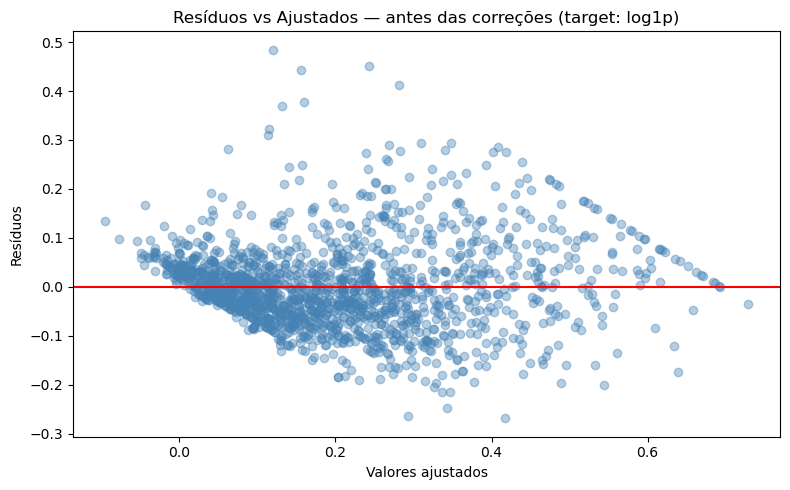

In [209]:
modelo_ols_antes = sm.OLS(y_train_log, sm.add_constant(X_train)).fit()
lm_antes, lm_p_antes, _, _ = het_breuschpagan(modelo_ols_antes.resid, modelo_ols_antes.model.exog)
print(f'Breusch-Pagan (antes) — LM: {lm_antes:.4f}  |  p-valor: {lm_p_antes:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(modelo_ols_antes.fittedvalues, modelo_ols_antes.resid, alpha=0.4, color='steelblue')
ax.axhline(0, color='red', linewidth=1.5)
ax.set_title('Resíduos vs Ajustados — antes das correções (target: log1p)')
ax.set_xlabel('Valores ajustados')
ax.set_ylabel('Resíduos')
plt.tight_layout()
plt.show()

Feature Engineering: Perfil de Cluster - tentar reduzir variância inconstante

KMeans (k=4) cria uma feature categórica que captura subpopulações latentes. Scaler e KMeans fit **apenas no treino**; teste usa `transform`/`predict`.

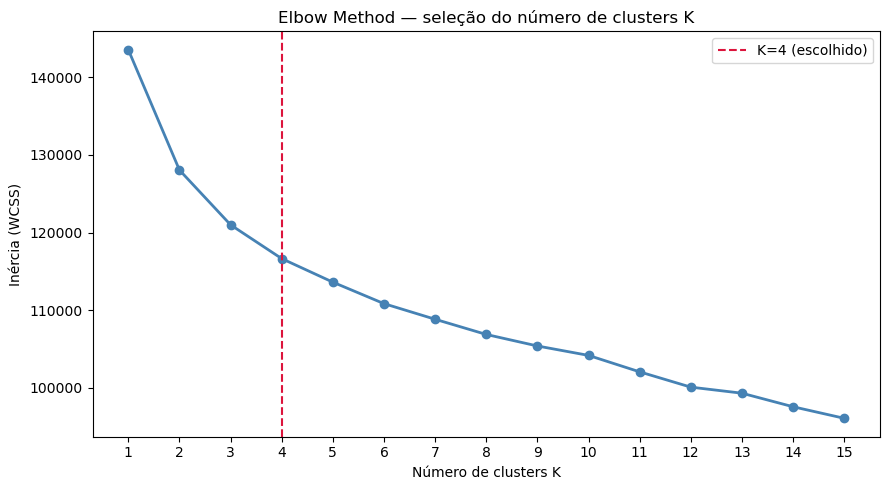

In [210]:
_scaler_elbow = StandardScaler()
_X_elbow = _scaler_elbow.fit_transform(X_train)

K_range = range(1, 16)
inercias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(_X_elbow).inertia_ for k in K_range]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), inercias, marker='o', color='steelblue', linewidth=2, markersize=6)
ax.axvline(4, color='crimson', linestyle='--', linewidth=1.5, label='K=4 (escolhido)')
ax.set_title('Elbow Method — seleção do número de clusters K')
ax.set_xlabel('Número de clusters K')
ax.set_ylabel('Inércia (WCSS)')
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()

In [211]:
scaler_km    = StandardScaler()
X_train_km   = scaler_km.fit_transform(X_train)
X_test_km    = scaler_km.transform(X_test)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
km.fit(X_train_km)
labels_train = km.predict(X_train_km)
labels_test  = km.predict(X_test_km)

perfis = []
for c in range(4):
    mask = labels_train == c
    perfis.append({
        'cluster': c,
        'n':       int(mask.sum()),
        'media_y': float(y_train.values[mask].mean()),
        'std_y':   float(y_train.values[mask].std()),
    })
pd.DataFrame(perfis)

,cluster,n,media_y,std_y
0,0,465,0.258366,0.214675
1,1,456,0.080833,0.072319
2,2,304,0.529112,0.255476
3,3,370,0.194649,0.139851


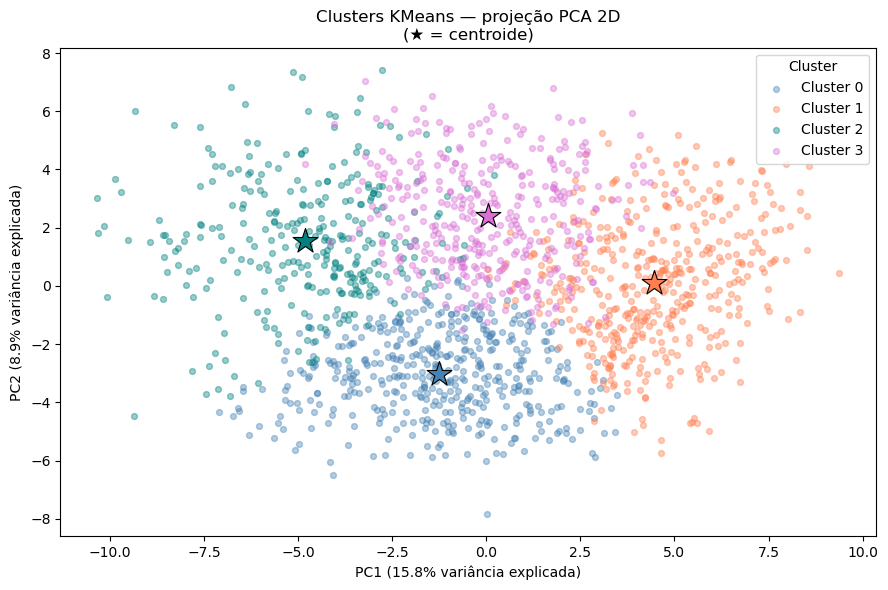

In [212]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_train_km)
centroides_pca = pca.transform(km.cluster_centers_)

palette = ['steelblue', 'coral', 'teal', 'orchid']
fig, ax = plt.subplots(figsize=(9, 6))
for c in range(km.n_clusters):
    mask = labels_train == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=palette[c], alpha=0.4, s=18, label=f'Cluster {c}')
    ax.scatter(centroides_pca[c, 0], centroides_pca[c, 1],
               color=palette[c], marker='*', s=350, edgecolors='black', linewidths=0.8)

ax.set_title('Clusters KMeans — projeção PCA 2D\n(★ = centroide)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variância explicada)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variância explicada)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [213]:
# Cluster dummies criadas apenas para diagnóstico BP — NÃO incluídas no modelo final.
# Ganho R²=+0.0014 não justifica complexidade; heterocedasticidade piora com cluster.
X_train_cluster = X_train.copy()
X_test_cluster  = X_test.copy()
X_train_cluster['perfil'] = labels_train
X_test_cluster['perfil']  = labels_test

dummies_train = pd.get_dummies(X_train_cluster['perfil'], prefix='perfil', drop_first=True, dtype=float)
dummies_test  = pd.get_dummies(X_test_cluster['perfil'],  prefix='perfil', drop_first=True, dtype=float)\
                  .reindex(columns=dummies_train.columns, fill_value=0)

X_train_cluster = X_train_cluster.drop(columns=['perfil']).join(dummies_train)
X_test_cluster  = X_test_cluster.drop(columns=['perfil']).join(dummies_test)
print(f'Shape X_train_cluster (diagnóstico): {X_train_cluster.shape}')
print('X_train / X_test finais NÃO contêm cluster.')

Shape X_train_cluster (diagnóstico): (1595, 93)
X_train / X_test finais NÃO contêm cluster.


## Breusch-Pagan — Após Cluster

Reteste com o novo X_train (inclui dummies de perfil). Comparação antes/depois para avaliar impacto da feature de cluster na heteroscedasticidade.

In [214]:
modelo_ols_depois = sm.OLS(y_train_log, sm.add_constant(X_train_cluster)).fit()
lm_depois, lm_p_depois, _, _ = het_breuschpagan(modelo_ols_depois.resid, modelo_ols_depois.model.exog)

pd.DataFrame({
    'momento':  ['antes (sem cluster)', 'depois (com cluster)'],
    'LM':       [lm_antes,   lm_depois],
    'p-valor':  [lm_p_antes, lm_p_depois],
    'R²':       [modelo_ols_antes.rsquared, modelo_ols_depois.rsquared],
})

,momento,LM,p-valor,R²
0,antes (sem cluster),188.396084,6.164247e-09,0.746692
1,depois (com cluster),207.196628,1.106759e-10,0.749201


In [215]:
df_delta = pd.DataFrame({
    'Δ LM':      [lm_depois - lm_antes],
    'Δ p-valor': [lm_p_depois - lm_p_antes],
    'Δ R²':      [modelo_ols_depois.rsquared - modelo_ols_antes.rsquared],
}, index=['depois − antes'])

df_delta.style.format({'Δ LM': '{:.4f}', 'Δ p-valor': '{:.2e}', 'Δ R²': '{:.6f}'})

,Δ LM,Δ p-valor,Δ R²
depois − antes,18.8005,-6.05e-09,0.002509


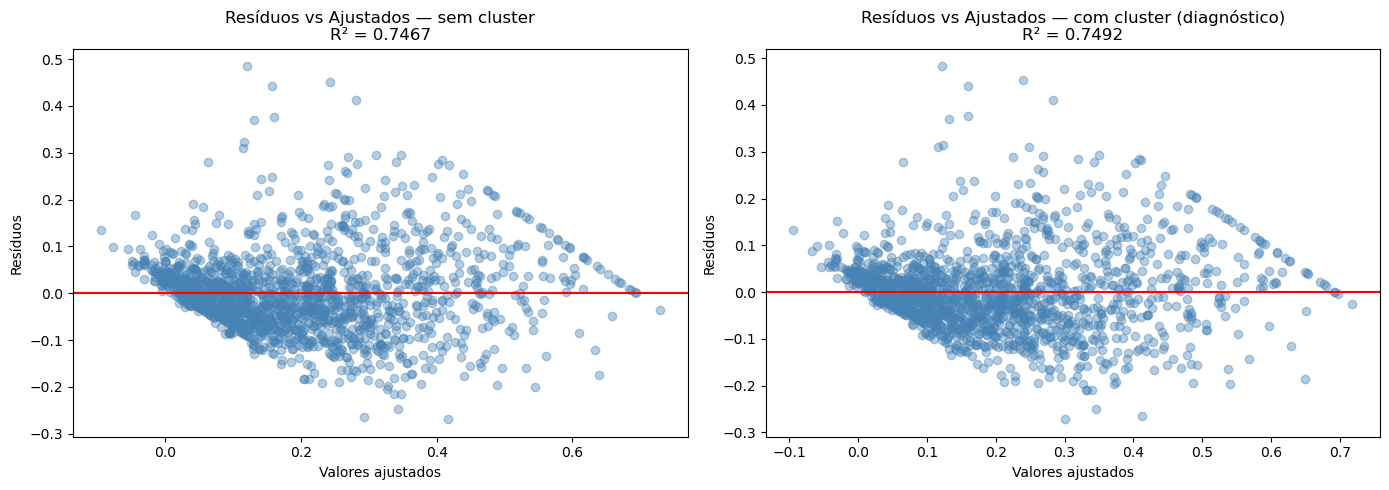

In [216]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, modelo, titulo in zip(axes,
                               [modelo_ols_antes, modelo_ols_depois],
                               ['sem cluster', 'com cluster (diagnóstico)']):
    ax.scatter(modelo.fittedvalues, modelo.resid, alpha=0.4, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5)
    ax.set_title(f'Resíduos vs Ajustados — {titulo}\nR² = {modelo.rsquared:.4f}')
    ax.set_xlabel('Valores ajustados')
    ax.set_ylabel('Resíduos')
plt.tight_layout()
plt.show()

=== OLS com erros HC3 ===
R²: 0.7467
F-stat (robusto): 55.6684  |  p-valor: 0.0000e+00

Top 5 coeficientes por |t| (HC3):


,coef,std_err,t,p
state_51,-0.1125,0.0180,-6.2404,0.0
state_12,0.1056,0.0190,5.5727,0.0
racePctWhite,-0.1695,0.0318,-5.3349,0.0
state_23,-0.0675,0.0153,-4.4199,0.0
state_28,-0.1557,0.0382,-4.0733,0.0



Ramsey RESET — F-stat: 91.6580  |  p-valor: 0.0000
Rejeita H₀: há evidência de não-linearidade na especificação.

Jarque-Bera — Estatística: 715.4166  |  p-valor: 4.4591e-156
Skewness resíduos: 0.9111  |  Curtose: 5.7285
Rejeita H₀: resíduos NÃO seguem distribuição normal.


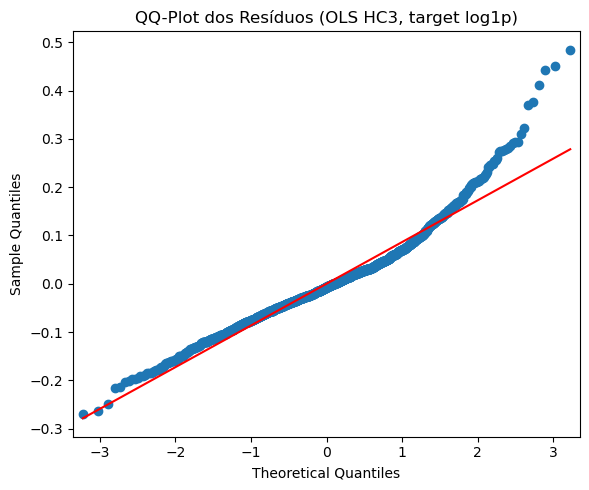

In [217]:
# ── Erros Padrão Robustos HC3 ─────────────────────────────────────────────────
# BP ainda rejeita H₀. HC3 corrige inferência (IC e p-valores) sem exigir WLS.
modelo_hc3 = sm.OLS(y_train_log, sm.add_constant(X_train)).fit(cov_type='HC3')

print('=== OLS com erros HC3 ===')
print(f'R²: {modelo_hc3.rsquared:.4f}')
print(f'F-stat (robusto): {modelo_hc3.fvalue:.4f}  |  p-valor: {modelo_hc3.f_pvalue:.4e}')

hc3_summary = pd.DataFrame({
    'coef':    modelo_hc3.params,
    'std_err': modelo_hc3.bse,
    't':       modelo_hc3.tvalues,
    'p':       modelo_hc3.pvalues,
}).drop('const', errors='ignore').sort_values('t', key=abs, ascending=False)
print('\nTop 5 coeficientes por |t| (HC3):')
display(hc3_summary.head(5).round(4))

# ── Teste RESET (Ramsey) — especificação funcional ────────────────────────────
reset_result = linear_reset(modelo_hc3, power=2, use_f=True)
print(f'\nRamsey RESET — F-stat: {reset_result.fvalue:.4f}  |  p-valor: {reset_result.pvalue:.4f}')
if reset_result.pvalue < 0.05:
    print('Rejeita H₀: há evidência de não-linearidade na especificação.')
else:
    print('Não rejeita H₀: especificação linear é adequada.')

# ── Normalidade dos Resíduos — Jarque-Bera ────────────────────────────────────
from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_p, skew_res, kurt_res = jarque_bera(modelo_hc3.resid)
print(f'\nJarque-Bera — Estatística: {jb_stat:.4f}  |  p-valor: {jb_p:.4e}')
print(f'Skewness resíduos: {skew_res:.4f}  |  Curtose: {kurt_res:.4f}')
if jb_p < 0.05:
    print('Rejeita H₀: resíduos NÃO seguem distribuição normal.')
else:
    print('Não rejeita H₀: resíduos compatíveis com normalidade.')

import statsmodels.graphics.gofplots as gg
fig, ax = plt.subplots(figsize=(6, 5))
gg.qqplot(modelo_hc3.resid, line='s', ax=ax)
ax.set_title('QQ-Plot dos Resíduos (OLS HC3, target log1p)')
plt.tight_layout()
plt.show()

## Treinamento dos Modelos

Pipeline com `StandardScaler` + modelo para evitar data leakage. Avaliação por MAE, MSE, RMSE e R² no conjunto de teste.

In [218]:
modelos = {
    'Regressão Linear': LinearRegression(),
    'Ridge':            Ridge(alpha=1.0),
    'Lasso':            Lasso(alpha=0.01, max_iter=10000),
}

modelos_treinados = {}
predicoes = {}
resultados = []

for nome, modelo in modelos.items():
    pipe = construir_pipeline(modelo)
    pipe.fit(X_train, y_train_log)                    # fit na escala log
    y_pred_log = pipe.predict(X_test)
    y_pred = np.expm1(y_pred_log)                     # reverte para escala original
    modelos_treinados[nome] = pipe
    predicoes[nome] = y_pred
    m = calcular_metricas(y_test, y_pred)
    resultados.append({'modelo': nome, **m})

df_teste = pd.DataFrame(resultados).set_index('modelo')
df_teste.round(4)

,MAE,MSE,RMSE,R2
modelo,,,,
Regressão Linear,0.0889,0.0165,0.1286,0.6547
Ridge,0.0889,0.0165,0.1286,0.6550
Lasso,0.0891,0.0172,0.1311,0.6411


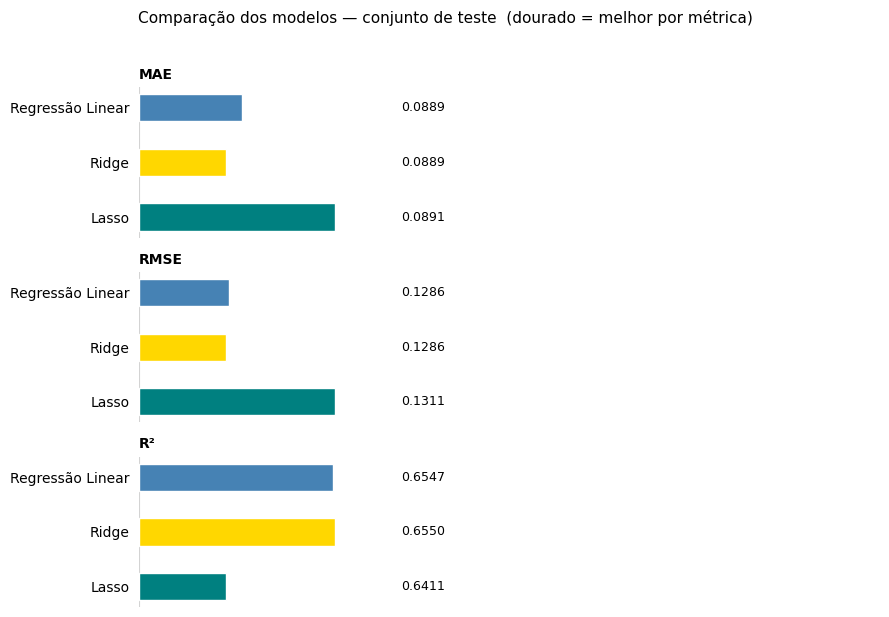

In [219]:
_pal   = ['steelblue', 'coral', 'teal']
_nomes = df_teste.index.tolist()
_mets  = [('MAE', 'MAE'), ('RMSE', 'RMSE'), ('R²', 'R2')]

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=False)
for ax, (label, col) in zip(axes, _mets):
    vals   = df_teste[col]
    melhor = vals.idxmin() if col != 'R2' else vals.idxmax()
    cores  = ['gold' if n == melhor else _pal[i] for i, n in enumerate(_nomes)]

    spread  = max(vals.max() - vals.min(), vals.mean() * 0.001)
    lo      = vals.min() - spread * 0.8
    hi      = vals.max() + spread * 5.0

    ax.barh(_nomes, vals - lo, left=lo, color=cores, edgecolor='white', height=0.5)
    ax.set_xlim(lo, hi)
    ax.axvline(lo, color='lightgray', linewidth=0.8, zorder=0)

    label_x = vals.max() + spread * 0.6
    for j, val in enumerate(vals):
        ax.text(label_x, j, f'{val:.4f}', va='center', ha='left', fontsize=9)

    ax.set_title(label, fontweight='bold', loc='left', fontsize=10)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(left=False)

fig.suptitle('Comparação dos modelos — conjunto de teste  (dourado = melhor por métrica)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Validação Cruzada

KFold 5-fold sobre o conjunto de treino para estimativa mais robusta da performance dos modelos.

In [220]:
kfold   = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}

resultados_cv = []
for nome, modelo in modelos.items():
    pipe   = construir_pipeline(modelo)
    scores = cross_validate(pipe, X_train, y_train_log, cv=kfold, scoring=scoring, n_jobs=-1)
    mse_cv = -scores['test_MSE'].mean()
    resultados_cv.append({
        'modelo':  nome,
        'MAE_CV':  -scores['test_MAE'].mean(),
        'MSE_CV':  mse_cv,
        'RMSE_CV': np.sqrt(mse_cv),
        'R2_CV':   scores['test_R2'].mean(),
    })

df_cv = pd.DataFrame(resultados_cv).set_index('modelo')
print('(Métricas na escala log1p do target)')
df_cv.round(4)

(Métricas na escala log1p do target)


,MAE_CV,MSE_CV,RMSE_CV,R2_CV
modelo,,,,
Regressão Linear,0.0678,0.0084,0.0919,0.7118
Ridge,0.0677,0.0084,0.0919,0.7120
Lasso,0.0727,0.0098,0.0991,0.6652


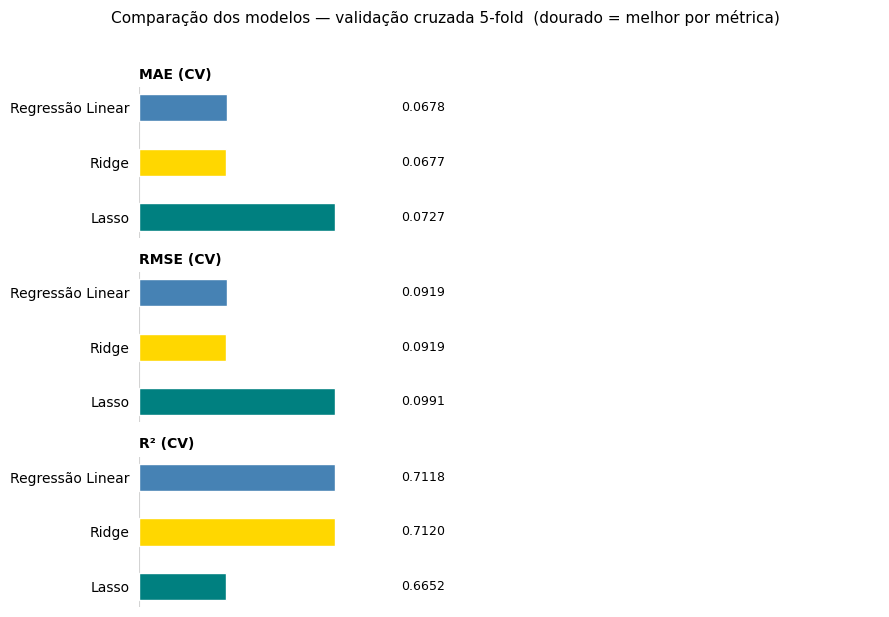

In [221]:
_pal_cv   = ['steelblue', 'coral', 'teal']
_nomes_cv = df_cv.index.tolist()
_mets_cv  = [('MAE (CV)', 'MAE_CV'), ('RMSE (CV)', 'RMSE_CV'), ('R² (CV)', 'R2_CV')]

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=False)
for ax, (label, col) in zip(axes, _mets_cv):
    vals   = df_cv[col]
    melhor = vals.idxmin() if col != 'R2_CV' else vals.idxmax()
    cores  = ['gold' if n == melhor else _pal_cv[i] for i, n in enumerate(_nomes_cv)]

    spread  = max(vals.max() - vals.min(), vals.mean() * 0.001)
    lo      = vals.min() - spread * 0.8
    hi      = vals.max() + spread * 5.0

    ax.barh(_nomes_cv, vals - lo, left=lo, color=cores, edgecolor='white', height=0.5)
    ax.set_xlim(lo, hi)
    ax.axvline(lo, color='lightgray', linewidth=0.8, zorder=0)

    label_x = vals.max() + spread * 0.6
    for j, val in enumerate(vals):
        ax.text(label_x, j, f'{val:.4f}', va='center', ha='left', fontsize=9)

    ax.set_title(label, fontweight='bold', loc='left', fontsize=10)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.tick_params(left=False)

fig.suptitle('Comparação dos modelos — validação cruzada 5-fold  (dourado = melhor por métrica)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Otimização de Hiperparâmetros — Grid Search

GridSearchCV com os mesmos folds da validação cruzada. O melhor modelo é selecionado pelo maior R² médio no CV.

In [222]:
alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 150, 200, 1000]

configs = {
    'Regressão Linear': {
        'modelo':     LinearRegression(),
        'param_grid': {'modelo__fit_intercept': [True, False]},
    },
    'Ridge': {
        'modelo':     Ridge(),
        'param_grid': {
            'modelo__alpha':         alphas,
            'modelo__fit_intercept': [True, False],
            'modelo__solver':        ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga'],
        },
    },
    'Lasso': {
        'modelo':     Lasso(max_iter=20000),
        'param_grid': {
            'modelo__alpha':         alphas,
            'modelo__fit_intercept': [True, False],
            'modelo__selection':     ['cyclic', 'random'],
        },
    },
}

resultados_grid = {}
linhas_grid     = []

for nome, cfg in configs.items():
    pipe = construir_pipeline(cfg['modelo'])
    gs   = GridSearchCV(pipe, cfg['param_grid'], cv=kfold, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train_log)                    # fit na escala log
    y_pred_log = gs.predict(X_test)
    y_pred     = np.expm1(y_pred_log)               # reverte para escala original
    m    = calcular_metricas(y_test, y_pred)
    best = {k.replace('modelo__', ''): v for k, v in gs.best_params_.items()}
    resultados_grid[nome] = gs
    linhas_grid.append({
        'modelo':       nome,
        'melhor_R2_CV': gs.best_score_,             # R² na escala log (CV)
        'MAE_teste':    m['MAE'],
        'MSE_teste':    m['MSE'],
        'RMSE_teste':   m['RMSE'],
        'R2_teste':     m['R2'],                    # R² na escala original
        **best,
    })

df_grid    = pd.DataFrame(linhas_grid).set_index('modelo')
melhor_idx = df_grid['melhor_R2_CV'].idxmax()

def _bold_best(row):
    return ['font-weight: bold' if row.name == melhor_idx else '' for _ in row]

df_grid.round(4).style.apply(_bold_best, axis=1)

,melhor_R2_CV,MAE_teste,MSE_teste,RMSE_teste,R2_teste,fit_intercept,alpha,solver,selection
modelo,,,,,,,,,
Regressão Linear,0.711800,0.088900,0.016500,0.128600,0.654700,True,nan,nan,nan
Ridge,0.712900,0.088600,0.016400,0.128200,0.657000,True,10.000000,lsqr,nan
Lasso,0.712200,0.088500,0.016400,0.128000,0.657700,True,0.000100,nan,random


## Visualização — Projeção PCA

PCA reduz todas as features preditoras a PC1 (direção de máxima variância). O scatter mostra os valores reais ao longo de PC1; a curva sobreposta são as predições do melhor modelo. O painel direito é o gráfico de calibração canônico para regressão multivariada.

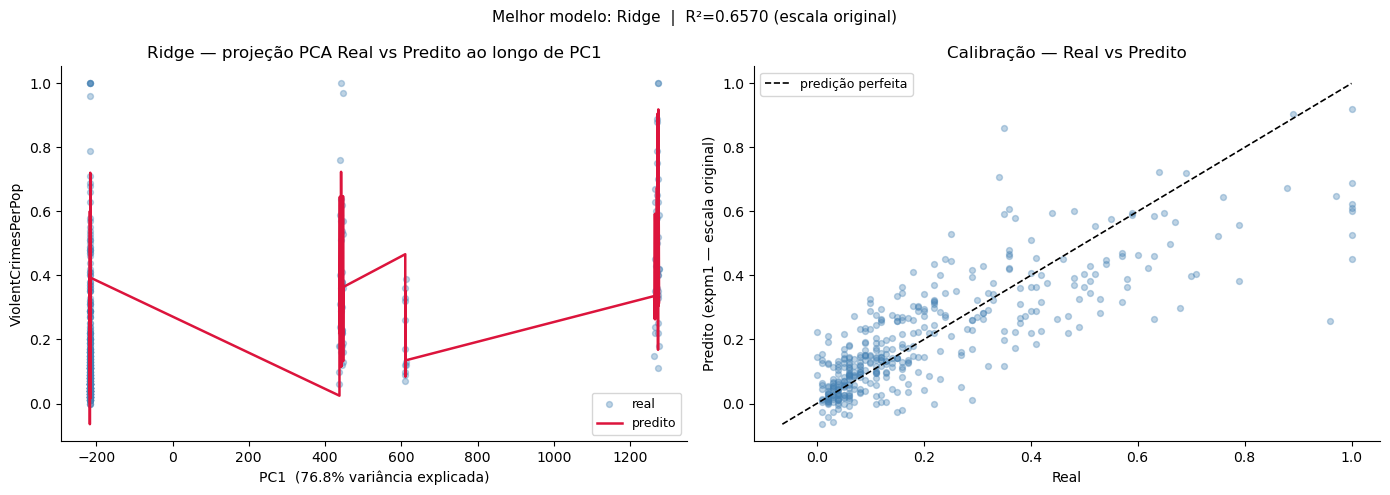

In [223]:
from sklearn.decomposition import PCA

nome_melhor = df_grid['melhor_R2_CV'].idxmax()
gs_melhor   = resultados_grid[nome_melhor]
best_params = {k.replace('modelo__', ''): v for k, v in gs_melhor.best_params_.items()}

y_pred_log_test = gs_melhor.best_estimator_.predict(X_test)
y_pred_test     = np.expm1(y_pred_log_test)          # escala original para visualização

pca     = PCA(n_components=1)
pc1     = pca.fit_transform(X_test).ravel()
var_exp = pca.explained_variance_ratio_[0]

order   = np.argsort(pc1)
pc1_s   = pc1[order]
y_act_s = np.array(y_test)[order]
y_prd_s = y_pred_test[order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(pc1_s, y_act_s, alpha=0.35, s=18, color='steelblue', label='real', zorder=2)
ax.plot(pc1_s, y_prd_s, color='crimson', linewidth=1.8, label='predito', zorder=3)
ax.set_xlabel(f'PC1  ({var_exp:.1%} variância explicada)')
ax.set_ylabel(TARGET)
ax.set_title(f'{nome_melhor} — projeção PCA Real vs Predito ao longo de PC1')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
lo  = min(float(y_test.min()), y_pred_test.min())
hi  = max(float(y_test.max()), y_pred_test.max())
ax2.scatter(y_test, y_pred_test, alpha=0.35, s=18, color='steelblue', zorder=2)
ax2.plot([lo, hi], [lo, hi], 'k--', linewidth=1.2, label='predição perfeita', zorder=3)
ax2.set_xlabel('Real')
ax2.set_ylabel('Predito (expm1 — escala original)')
ax2.set_title('Calibração — Real vs Predito')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

r2_grid = df_grid.loc[nome_melhor, 'R2_teste']
plt.suptitle(f'Melhor modelo: {nome_melhor}  |  R²={r2_grid:.4f} (escala original)', fontsize=11)
plt.tight_layout()
plt.show()

## Efeito Parcial por Feature

Para o melhor modelo, varia-se cada feature individualmente (as demais fixadas na média) para visualizar o efeito marginal de cada preditor.

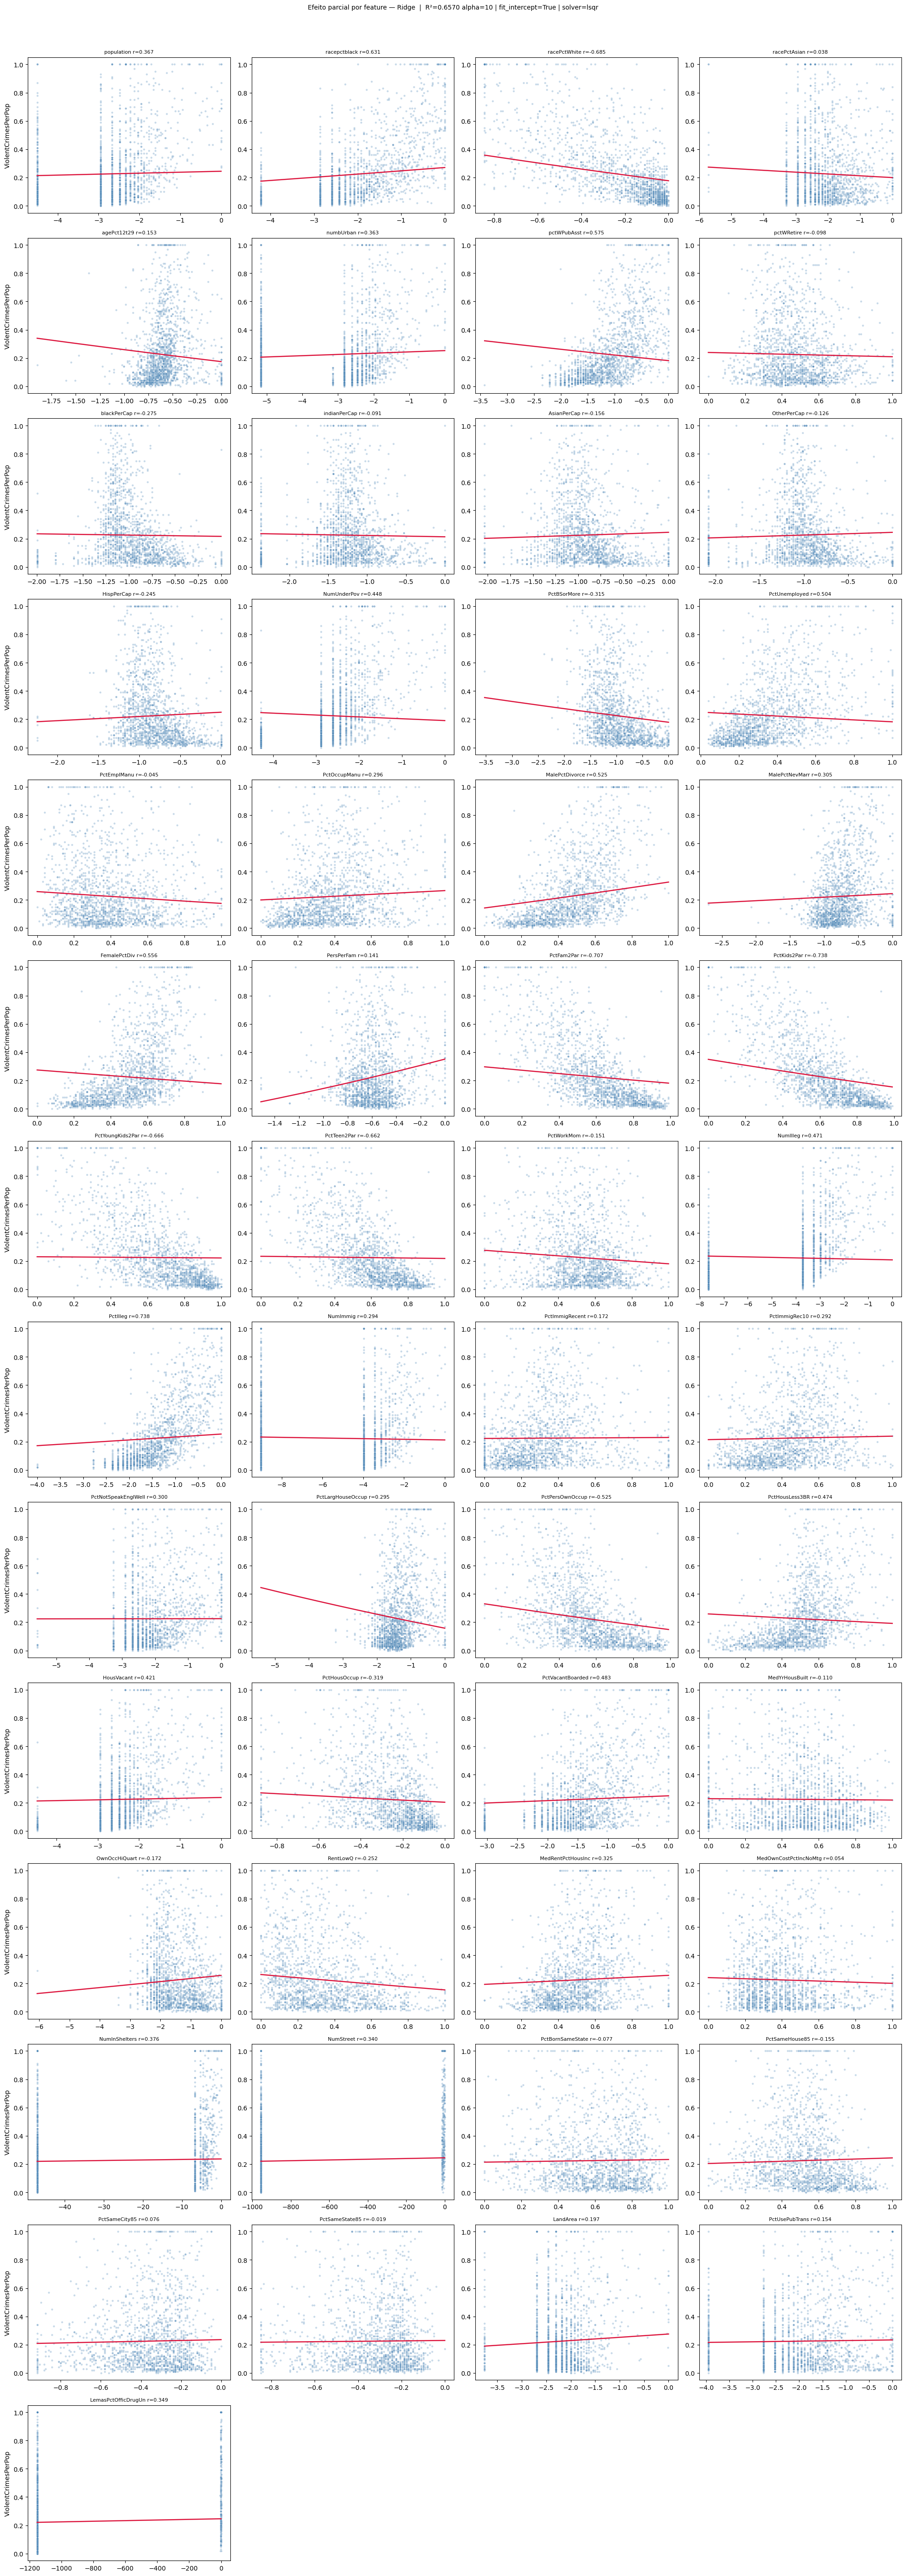

In [224]:
# pipe_full treinado em X_train (treino apenas) — correto para interpretação
pipe_full = clone(gs_melhor.best_estimator_)
pipe_full.fit(X_train, y_train_log)
medias = X_train.mean()

features_plot = [f for f in selected_features_lasso if not f.startswith('state_')]
n_f     = len(features_plot)
ncols_f = 4
nrows_f = math.ceil(n_f / ncols_f)

fig, axes = plt.subplots(nrows_f, ncols_f, figsize=(5 * ncols_f, 4 * nrows_f))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    corr_val = tabela_corr.loc[feat, 'correlacao'] if feat in tabela_corr.index else float('nan')
    x_range  = np.linspace(X_train[feat].min(), X_train[feat].max(), 200)
    X_par    = pd.DataFrame(np.tile(medias.values, (200, 1)), columns=selected_features_lasso)
    X_par[feat] = x_range
    y_lin_p  = np.expm1(pipe_full.predict(X_par))   # reverte log1p → escala original

    ax = axes[i]
    sns.scatterplot(x=X_train[feat], y=y_train.values, alpha=0.3, s=10, color='steelblue', ax=ax)
    ax.plot(x_range, y_lin_p, color='crimson', linewidth=1.8)
    ax.set_title(f'{feat} r={corr_val:.3f}', fontsize=8)
    ax.set_ylabel(TARGET if i % ncols_f == 0 else '')
    ax.set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

params_str = ' | '.join(f'{k}={v}' for k, v in best_params.items())
r2_grid    = df_grid.loc[nome_melhor, 'R2_teste']
fig.suptitle(f'Efeito parcial por feature — {nome_melhor}  |  R²={r2_grid:.4f} {params_str}',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

## Comparação Final

Resultados consolidados: teste, validação cruzada e melhor configuração encontrada pelo Grid Search.

In [225]:
comparacao = df_teste.join(df_cv)
print('=== Teste vs Validação Cruzada ===')
display(comparacao.round(4))

print('\n=== Grid Search — melhores configurações ===')
display(df_grid.round(4))

=== Teste vs Validação Cruzada ===


,MAE,MSE,RMSE,R2,MAE_CV,MSE_CV,RMSE_CV,R2_CV
modelo,,,,,,,,
Regressão Linear,0.0889,0.0165,0.1286,0.6547,0.0678,0.0084,0.0919,0.7118
Ridge,0.0889,0.0165,0.1286,0.6550,0.0677,0.0084,0.0919,0.7120
Lasso,0.0891,0.0172,0.1311,0.6411,0.0727,0.0098,0.0991,0.6652



=== Grid Search — melhores configurações ===


,melhor_R2_CV,MAE_teste,MSE_teste,RMSE_teste,R2_teste,fit_intercept,alpha,solver,selection
modelo,,,,,,,,,
Regressão Linear,0.7118,0.0889,0.0165,0.1286,0.6547,True,NaN,NaN,NaN
Ridge,0.7129,0.0886,0.0164,0.1282,0.6570,True,10.0000,lsqr,NaN
Lasso,0.7122,0.0885,0.0164,0.1280,0.6577,True,0.0001,NaN,random
